In [1]:
cd /lustre/fsn1/projects/rech/omr/romr004/code/dinostics

/lustre/fsn1/projects/rech/omr/romr004/code/dinostics


In [2]:
from matplotlib import colors
from matplotlib import pyplot as plt
import numpy as np
import xarray as xr
import cftime as cft    
import xnemogcm as xn
import xgcm
import cmocean as cm
from datetime import datetime
from pathlib import Path

In [3]:
import importlib
import experiment
importlib.reload(experiment)
from experiment import NemoExperiment

# Convert numpy field to Nemo Restart file

Step 1 : convert numpy file to 1° simulation -> `generated_restart_<generation_name>_1deg.`

Step 2 : upsample 1° simulation to 1/4° simulation

Step 3 : create new 1/4° restart from upsampled prediction -> `generated_restart_<generation_name>_1_4deg.`

In [4]:
base_references = "/lustre/fsn1/projects/rech/omr/uym68qx/DINO/"
references = {'1deg' : 'Blandine/1deg_restart', '1_4deg' : 'Blandine/restart25_arch'}

base_path_generated = "/lustre/fsn1/projects/rech/omr/romr004/DiffusionStates/"
generation_name = 'C2'

## Step 1 : 

In [5]:
idx_batch = 4 # which generated field to run the simulation on

generation_path = f'{base_path_generated}/{generation_name}'
soce = np.load(f'{generation_path}/soce.npy')[idx_batch,:,:,:]
toce = np.load(f'{generation_path}/toce.npy')[idx_batch,:,:,:]
ssh = np.load(f'{generation_path}/ssh.npy')[idx_batch,:,:]

print(f'{soce.shape=} {toce.shape=} {ssh.shape=}')

soce.shape=(36, 199, 62) toce.shape=(36, 199, 62) ssh.shape=(1, 199, 62)


In [6]:
# Reference 1° simulation
exp_1deg = NemoExperiment(
    path=base_references,
    experiment_name=references['1deg'],
)

# Example of restart file from 1°
restart_dummy = exp_1deg.open_restart().load()

[PurePosixPath('/lustre/fsn1/projects/rech/omr/uym68qx/DINO/Blandine/1deg_restart/DINO_00000002_restart.nc')]


/lustre/fsn1/projects/rech/omr/romr004/code/dinostics/experiment.py:121: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


In [7]:
# Compute variables to add in restart dummy 

nml = exp_1deg.namelist['nameos']
z = exp_1deg.mask.gdept_0.data

rhop  = (
        - nml['rn_a0'] * (1. + 0.5 * nml['rn_lambda1'] * ( toce - 10.) + nml['rn_mu1'] * z) * ( toce - 10.) 
        + nml['rn_b0'] * (1. - 0.5 * nml['rn_lambda2'] * ( soce - 35.) - nml['rn_mu2'] * z) * ( soce - 35.) 
        - nml['rn_nu'] * ( toce - 10.) * ( soce - 35.)
) + 1026

tmask = exp_1deg.mask.tmask.load().data


restart_dummy['tb'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(toce,axis=0))
restart_dummy['tn'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(toce,axis=0))

restart_dummy['sb'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(soce,axis=0))
restart_dummy['sn'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(soce,axis=0))

restart_dummy['sshb'] = (('time_counter', 'y', 'x'), ssh)
restart_dummy['sshn'] = (('time_counter', 'y', 'x'), ssh)

restart_dummy['rhop'] = (('time_counter', 'nav_lev', 'y', 'x'), np.expand_dims(rhop, axis=0))

# Update name and datetime
restart_dummy.attrs['file_name'] = f'generated_restart_{generation_name}_1deg.nc'
restart_dummy.attrs['TimeStamp'] = datetime.now().astimezone().strftime('%d/%m/%Y %H:%M:%S %z')

# Save restart file 1°
path_save = base_path_generated + restart_dummy.attrs['file_name']
Path(path_save).unlink(missing_ok=True)
restart_dummy.to_netcdf( path_save, unlimited_dims='time_counter')
print(f'Saved {path_save}')

Saved /lustre/fsn1/projects/rech/omr/romr004/DiffusionStates/generated_restart_C2_1deg.nc


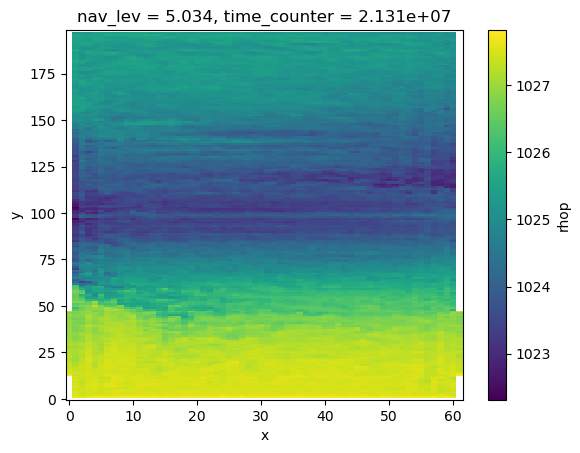

In [8]:
restart_dummy.rhop.isel(nav_lev=0).plot()

## Step 2 : upsampling 1° -> 1/4°

In [9]:
# Load reference 1/4° experiment to get grid
exp_1_4deg = NemoExperiment(
    path=base_references,
    experiment_name=references['1_4deg']
)

In [10]:
# Upsample from 1° to 1/4°
restart_interpolated = exp_1deg.grid_manipulation.regrid_restart(exp_1_4deg, restart_path=path_save)

[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/DiffusionStates/generated_restart_C2_1deg.nc')]
1025.2245


/lustre/fsn1/projects/rech/omr/romr004/code/dinostics/experiment.py:121: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


1025.2218
[PurePosixPath('/lustre/fsn1/projects/rech/omr/uym68qx/DINO/Blandine/restart25_arch/DINO_10800000_restart.nc')]


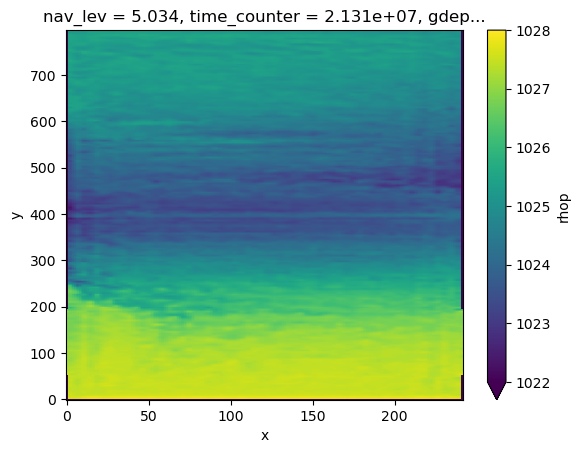

In [12]:
restart_interpolated.rhop.isel(nav_lev=0, time_counter=0).plot(vmin=1022, vmax=1028)

## Step 3 : Create 1/4° restart

In [13]:
# Get restart file + replace the field generated (Temperature, Salinity, SSH)
restart_new = exp_1_4deg.open_restart().load().copy()


for field in ['tn', 'tb', 'sn', 'sb', 'un', 'ub', 'vn', 'vb', 'rhop']:
    restart_new[field] = (('time_counter', 'nav_lev', 'y', 'x'), restart_interpolated[field].data)
for field in ['sshn', 'sshb']:
    restart_new[field] = (('time_counter', 'y', 'x'), restart_interpolated[field].data)

restart_new = restart_new.fillna(0.)
restart_new = restart_new.chunk({'time_counter':1, 'y':797, 'x':242, 'nav_lev':36}).compute()

[PurePosixPath('/lustre/fsn1/projects/rech/omr/uym68qx/DINO/Blandine/restart25_arch/DINO_10800000_restart.nc')]


In [23]:
# Update name and datetime
restart_new.attrs['file_name'] = f'generated_restart_{generation_name}_1_4deg.nc'
restart_new.attrs['TimeStamp'] = datetime.now().astimezone().strftime('%d/%m/%Y %H:%M:%S %z')

# Save restart file 1°
path_save_1_4 = base_path_generated + restart_new.attrs['file_name']
Path(path_save_1_4).unlink(missing_ok=True)
restart_new.to_netcdf(path_save_1_4, unlimited_dims='time_counter')
print(f'Saved {path_save_1_4} \n     Time counter (for nn_it000) : {restart_new.time_counter.data[0]}')

Saved /lustre/fsn1/projects/rech/omr/romr004/DiffusionStates/generated_restart_C2_1_4deg.nc 
     Time counter (for nn_it000) : 10800000.0


# Verification

In [24]:
generated  = exp_1_4deg.open_restart(restart_path=path_save_1_4)

[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/DiffusionStates/generated_restart_C2_1_4deg.nc')]


/lustre/fsn1/projects/rech/omr/romr004/code/dinostics/experiment.py:121: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


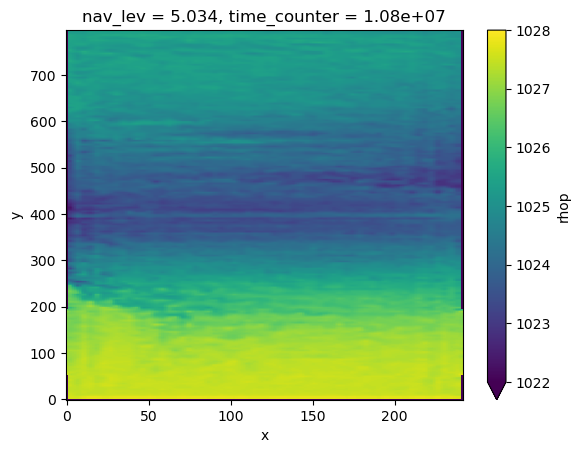

In [26]:
generated.rhop.isel(nav_lev=0).plot(vmin=1022, vmax=1028)